In [1]:
""" example code for fitting SEDs """
# pylint: disable=invalid-name, no-member, missing-function-docstring, un line-too-long
import warnings
from pathlib import Path
import json
import re

import numpy as np

import corner

# Support for interactive widgets
from IPython.display import display
from ipywidgets import Dropdown

# %matplotlib widget
import matplotlib.pyplot as plt

# pylint: disable=wrong-import-position
warnings.filterwarnings("ignore", "Using UFloat objects with std_dev==0 may give unexpected results.", category=UserWarning)
from uncertainties import ufloat, nominal_value as nom_val
from uncertainties.unumpy import nominal_values
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia

from dust_extinction.parameter_averages import F99, F04, G23

from deblib.constants import M_sun, R_sun
from deblib.stellar import log_g

from support.extinction import get_gontcharov_av
from support.pipeline import get_teff_from_spt
from support.sed import get_sed_for_target, retain_only_closest_observations
from support.plots import plot_sed, plot_fitted_model

from sed_fit.fitter import create_theta, model_func, minimize_fit, mcmc_fit, samples_from_sampler
from sed_fit.stellar_grids import get_stellar_grid

### Set up the extinction model

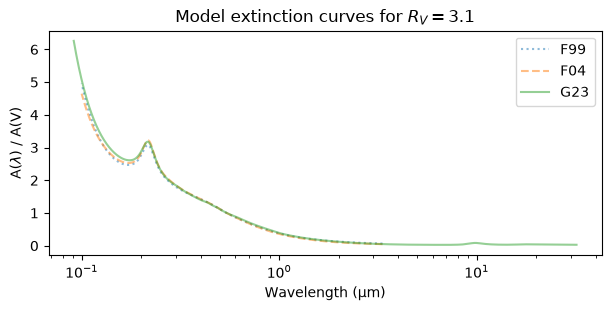

Using the G23 extinction model covers the range from 0.0912 µm to 32.0 µm.


In [2]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), constrained_layout=True)
for (_mod, _ls) in [(F99, ":"), (F04, "--"), (G23, "-")]:
    _lambda = (1 / np.logspace(*np.log10(_mod.x_range), num=1000)) * u.um
    ax.plot(_lambda, _mod(Rv=3.1)(_lambda), ls=_ls, alpha=0.5, label=f"{_mod.name}")
ax.set(title="Model extinction curves for $R_V=3.1$", xscale="log",
       xlabel=f"Wavelength ({_lambda.unit:latex_inline})", ylabel=r"A($\lambda$) / A(V)")
ax.legend(loc="best")
plt.show(fig)
plt.close(fig)

# The G23 (Gordon et al., 2023) Milky Way R(V) filter gives us the broadest coverage
ext_model = G23(Rv=3.1)
ext_wl_range = np.reciprocal(ext_model.x_range) * u.um # x_range has implicit units of 1/micron
print(f"Using the {ext_model.__class__.__name__} extinction model covers the range from",
      f"{min(ext_wl_range):unicode} to {max(ext_wl_range):unicode}.")

### Load the model grid used for generating synthetic SEDs 
These create a flux interpolator over grid of fluxes across a range of $T_{\rm eff}$, $\log{g}$
and metallicities. The grids support the option of "quick mode" which creates a further set of
interpolators for pre-filtered and summed fluxes for each supported filter, over the same ranges.
When using quick mode, any extinction calculations are simplified by being made after the filter
and treating all of the flux as a single value with the filter's mean wavelength.

In [3]:
use_quick_mode = True

# Both BtSettlGrid & KuruczGrid available with the former having better coverage but slower/larger
model_grid = get_stellar_grid("BtSettlGrid", extinction_model=ext_model,
                              use_quick_mode=use_quick_mode, verbose=True)

print(f"Loaded {model_grid.__class__.__name__} covering the ranges:")
print(f"wavelength {model_grid.wavelength_range * model_grid.wavelength_unit:unicode},",
      f"Teff {model_grid.teff_range * model_grid.teff_unit:unicode},",
      f"logg {model_grid.logg_range * model_grid.logg_unit:unicode}",
      f"\nand metallicity {model_grid.metal_range * u.dimensionless_unscaled:unicode},",
      f"with fluxes returned in units of {model_grid.flux_unit:unicode}")

Loading model grid from bt-settl-agss.npz created at 2025-11-19 18:41:01.266422+00:00
BtSettlGrid is initializing the fluxes interpolator with a grid of 112 teff, 6 logg & 4 metal values and 5000 wavelength bins...will use slinear interpolation...done.
The use of quick mode requested so will set up pre-filtered fluxes.
Initializing pre-filtered fluxes for 38 filters......................................done.
Loaded BtSettlGrid covering the ranges:
wavelength [ 0.09120575 31.99861909] µm, Teff [ 2000. 40000.] K, logg [3.  5.5] dex 
and metallicity [-0.5  0.5], with fluxes returned in units of W m⁻²


### Select our target and get its known information

In [4]:
default_target = "AI Phe"
fit_av = True
targets_config_file = Path.cwd() / "config" / "fitting-a-sed-targets.json"
with open(targets_config_file, mode="r", encoding="utf8") as f:
    full_dict = json.load(f)
targets_cfg = { k: full_dict[k] for k in full_dict if full_dict[k].get("enabled", True) }

max_teff = max(model_grid.teff_range * model_grid.teff_unit).to(u.K).value
options = [
    (f"{t}" + (" *" if c.get("exclude", False) else "") + (" [too hot!]" if min(c["Teff1"], c["Teff2"]) > max_teff else ""), t)
        for t, c in targets_cfg.items()
]

target_selection = Dropdown(options=options, value=default_target, description="Targets:")
display(target_selection)

Dropdown(description='Targets:', index=25, options=(('V436 Per', 'V436 Per'), ('V539 Ara', 'V539 Ara'), ('MU C…

In [5]:
target = target_selection.value
target_config = targets_cfg[target]
target_config.setdefault("logg1", log_g(target_config["M1"] * M_sun, target_config["R1"] * R_sun).n)
target_config.setdefault("logg2", log_g(target_config["M2"] * M_sun, target_config["R2"] * R_sun).n)

# Additional data on the target populated with lookups
target_data = {
    "label": target_config.get("label", target),
    "search_term": target_config.get("search_term", target)
}

_simbad = Simbad()
_simbad.add_votable_fields("sp", "ids")
if _tbl := _simbad.query_object(target_data["search_term"]):
    target_data["ids"] = np.array(re.findall(r"(Gaia DR3|V\*|TIC|HD|HIP|2MASS)\s+(.+?(?=\||$))", _tbl["ids"][0]),
                                    dtype=[("type", object), ("id", object)])
    print("IDs:", ", ".join(f"{i['type']} {i['id']}" for i in target_data["ids"]))
    target_data["spt"] = _tbl["sp_type"][0]
    print("SpT:", target_data["spt"])

IDs: TIC 102069549, HIP 5438, Gaia DR3 4933562966514402176, 2MASS J01093419-4615560, HD 6980, V* BV  1513, V* AI Phe
SpT: F7V+K0IV


In [6]:
# Let's get the Gaia DR3 data on this here object
_gaia_dr3_id = target_data["ids"][target_data["ids"]["type"] == "Gaia DR3"]["id"][0]
if _job := Gaia.launch_job(f"SELECT TOP 1 * FROM gaiadr3.gaia_source_lite WHERE source_id = {_gaia_dr3_id}"):
    _tbl = _job.get_results()
    target_data["ruwe"] = _tbl["ruwe"][0]
    target_data["distance"] = 1000 / ufloat(_tbl["parallax"][0], _tbl["parallax_error"][0])
    target_data["skycoords"] = _coords = SkyCoord(ra=_tbl["ra"][0] * u.deg, dec=_tbl["dec"][0] * u.deg,
                                                  distance=1000 / _tbl["parallax"][0] * u.pc, frame="icrs")
    print(f"{target} SkyCoords are {_coords} (or {_coords.to_string('hmsdms')})")
    print(f"ruwe = {target_data.get('ruwe', 0):.3f}")

AI Phe SkyCoords are <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    (17.39283047, -46.26557313, 169.29466543)> (or 01h09m34.27931365s -46d15m56.06325506s)
ruwe = 1.149


In [7]:
# Lookup the TESS Input Catalog (8.2) for starting "system" Teff and logg values
target_data["teff_sys"] = get_teff_from_spt(target_data["spt"]) or ufloat(5700, 0)
target_data["logg_sys"] = ufloat(4.0, 0)
if _tbl := Vizier(catalog="IV/39/tic82").query_object(target_data["search_term"], radius=0.1 * u.arcsec):
    if _row := _tbl[0][_tbl[0]["TIC"] in target_data["ids"][target_data["ids"]["type"] == "TIC"]["id"]]:
        # Teff may not be reliable - only use it if it's consistent with the SpT
        if target_data["teff_sys"].n-target_data["teff_sys"].s < (_row["Teff"] or 0) < target_data["teff_sys"].n+target_data["teff_sys"].s:
            target_data["teff_sys"] = ufloat(_row["Teff"], _row.get("s_Teff", None) or 0)
        if (_row["logg"] or 0) > 0:
            target_data["logg_sys"] = ufloat(_row["logg"], _row.get("s_logg", None) or 0)

# Other priors will likely come out of light curve fitting with JKTEBOP - get from config for now
target_data["k"] = ufloat(target_config.get("k"), target_config.get("k_err", 0) or 0)
if "light_ratio" in target_config:
    target_data["light_ratio"] = ufloat(target_config.get("light_ratio"), target_config.get("light_ratio_err", 0) or 0)
else:
    # If from LC fit we may also need to consider 3L; l1=(1-3L)/(1+(L2/L1)) & l2=(1-3L)/(1+1/(L2/L1))
    target_data["light_ratio"] = ufloat(10**(target_config.get("logL2", 1) - target_config.get("logL1", 1)), 0)
target_data["teff_ratio"] = (target_data["light_ratio"] / target_data["k"]**2)**0.25

print(f"{target} system values from lookup and LC fitting:")
for p, unit in [("distance", u.pc), ("teff_sys", u.K), ("logg_sys", u.dex), ("k", None), ("light_ratio", None), ("teff_ratio", None)]:
    print(f"{p:>12s} = {target_data[p]:.3f} {unit or u.dimensionless_unscaled:unicode}")

AI Phe system values from lookup and LC fitting:
    distance = 169.295+/-0.547 pc
    teff_sys = 6700.000+/-500.000 K
    logg_sys = 4.000+/-0 dex
           k = 1.625+/-0.003 
 light_ratio = 1.112+/-0 
  teff_ratio = 0.805+/-0.001 


### Get the SED data for the target
The initial call the `get_sed_for_target()` will query the
[VizieR Photometry service](https://vizier.cds.unistra.fr/vizier/sed/doc/). This aggregates and returns
photometric observations from across the platform's many catalogues within a chosen radius of the target.
Once received, the table is pre-processed to ensure consistent units, apply default uncertainties where
missing and to remove duplicate rows.

The call to `retain_only_closest_observations()` then removes all but one observation per filter,
with the closes to the target's coordinates being retained.

Finally, the table is further restricted to remove observations with filters not supported by
the stellar model or any that have been explicitly listed for exclusion.

In [8]:
# Read in the SED for this target and de-duplicate (measurements may appear multiple times).
sed = get_sed_for_target(target, target_data["search_term"], radius=0.25, remove_duplicates=True,
                         freq_unit=u.GHz, flux_unit=u.Jy, wl_unit=u.um, verbose=True)
sed = retain_only_closest_observations(sed, target_data["skycoords"])

model_mask = np.ones((len(sed)), dtype=bool)
model_mask &= model_grid.has_filter(sed["sed_filter"])
model_mask &= np.isin(sed["sed_filter"], target_config.get("sed_filter_exclusions",[]), invert=True)
model_mask &= np.isin(sed["_tabname"], target_config.get("sed_tabname_exclusions", []), invert=True)
model_mask &= (sed["sed_wl"] >= min(model_grid.wavelength_range)) \
            & (sed["sed_wl"] <= max(model_grid.wavelength_range))
sed = sed[model_mask]

sed.sort(["sed_wl"])
print(f"{len(sed)} unique SED observation(s) retained after range & exclusion filtering,",
      "and the selection of the 'closest' observation to the target for each Filter.",
      "\nThe units for flux density, frequency and wavelength are:",
      ", ".join(f"{sed[f].unit:unicode}" for f in ["sed_flux", "sed_freq", "sed_wl"]))
print("Filters (by wavelength):", ", ".join(sed["sed_filter"]))
print("Fluxes (by wavelength):", ", ".join(f"{f:.2e}" for f in sed['sed_flux']))

Opened SED table ai-phe-0.25.vot containing 106 row(s).
Dropped 10 duplicate(s) leaving 96 unique row(s).
14 unique SED observation(s) retained after range & exclusion filtering, and the selection of the 'closest' observation to the target for each Filter. 
The units for flux density, frequency and wavelength are: Jy, GHz, µm
Filters (by wavelength): Johnson:B, Johnson:V, SDSS:i, 2MASS:J, Johnson:J, Johnson:H, 2MASS:H, 2MASS:Ks, Johnson:K, WISE:W1, Johnson:L, WISE:W2, WISE:W3, WISE:W4
Fluxes (by wavelength): 8.50e-01, 1.35e+00, 1.49e+00, 1.89e+00, 1.93e+00, 1.75e+00, 1.77e+00, 1.26e+00, 1.22e+00, 6.24e-01, 5.86e-01, 3.28e-01, 5.49e-02, 1.58e-02


### Get the extinction $A_{\rm V}$ value for the target
We have the option of fitting the extinction value $A_{\rm V}$, or we can de-redden the
observations in advance and fix the fitted extinction at zero. The latter approach is quicker as
the extinction calculations are carried out once only rather than on each fitting iteration.

Will fit extinction based Av=0.231+/-0.124


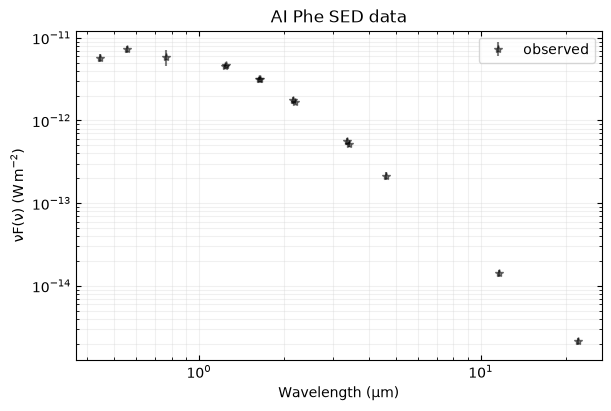

In [9]:
if "ebv" in target_config:
    Av = ufloat(target_config["ebv"], target_config.get("ebv_err", 0)) * 3.1
elif "av" in target_config:
    Av = ufloat(target_config["av"], target_config.get("av_err", 0))
else:
    Av = ufloat(get_gontcharov_av(target_data["skycoords"])[0], 0.04 * 3.1)

if fit_av:
    print(f"Will fit extinction based Av={Av:.3f}")
    sed["sed_fit_flux"] = sed["sed_flux"]
    fig = plot_sed(sed["sed_wl"].quantity,
                   fluxes=[sed["sed_fit_flux"].quantity],
                   flux_errs=[sed["sed_eflux"].quantity],
                   fmts=["*k"],
                   labels=["observed"],
                   show_grid=True,
                   title=target_data['label'] + " SED data")
else:
    print(f"Will not fit extinction, so dereddening SED observations with Av={nom_val(Av):.3f}")
    sed["sed_fit_flux"] = sed["sed_flux"] / ext_model.extinguish(sed["sed_wl"].to(u.um), Av=nom_val(Av))
    fig = plot_sed(sed["sed_wl"].quantity,
                   fluxes=[sed["sed_flux"].quantity, sed["sed_fit_flux"].quantity],
                   flux_errs=[sed["sed_eflux"].quantity]*2,
                   fmts=["*k", ".b"],
                   labels=["observed", f"dereddened\n($A_{{\\rm V}}={Av:.3f})$"],
                   show_grid=True,
                   title=target_data['label'] + " SED data")
plt.show(fig)
plt.close(fig)

### Set up the functions which will support fitting

In [10]:
NUM_STARS = 2

theta_plot_labels = np.array([f"$T_{{\\rm eff,{st+1}}} / {{\\rm K}}$" for st in range(NUM_STARS)] \
                            +[f"$\\log{{g}}_{{\\rm {st+1}}}$" for st in range(NUM_STARS)] \
                            +[f"$R_{{\\rm {st+1}}} / {{\\rm R_{{\\odot}}}}$" for st in range(NUM_STARS)] \
                            +["${\\rm dist} / {\\rm pc}$", "${\\rm A_{V}}$"])

theta_labels = np.array([(f"Teff{st+1}", u.K) for st in range(NUM_STARS)] \
                        +[(f"logg{st+1}", u.dex) for st in range(NUM_STARS)] \
                        +[(f"R{st+1}", u.Rsun) for st in range(NUM_STARS)] \
                        +[("dist", u.pc), ("av", u.dimensionless_unscaled)])

We set the starting position for the fit, `theta0`, which is our best estimate of the
fitted values for the system based on existing published data and any light-curve fitting carried
out previously.

The `fit_mask` indicates which of the values in `theta0` a free, with the remainder being fixed.

In [11]:
theta0 = create_theta(teffs=[nom_val(target_data["teff_sys"])] * NUM_STARS,
                      loggs=[nom_val(target_data["logg_sys"])] * NUM_STARS,
                      radii=[1.0] * NUM_STARS,
                      dist=nom_val(target_data["distance"]),
                      av=nom_val(Av) if fit_av else 0,
                      nstars=NUM_STARS,
                      verbose=False)

fit_mask = np.array([True] * NUM_STARS      # teff
                  + [False] * NUM_STARS     # logg
                  + [True] * NUM_STARS      # radius
                  + [True]                  # dist
                  + [fit_av])               # av (we've handled av by derredening the SED)

print(f"For {target} we set the starting position (theta0) to be:",
    *(f"\n{l:>9s}{'*' if fit_mask[ix] else ' '} = {theta0[ix]:.3f} {unit:unicode}"
                    for ix, (l, unit) in enumerate(theta_labels)),
    "\nThose marked with * will be fitted.")

For AI Phe we set the starting position (theta0) to be: 
    Teff1* = 6700.000 K 
    Teff2* = 6700.000 K 
    logg1  = 4.000 dex 
    logg2  = 4.000 dex 
       R1* = 1.000 R☉ 
       R2* = 1.000 R☉ 
     dist* = 169.295 pc 
       av* = 0.231  
Those marked with * will be fitted.


Here we set up priors' limit and ratio criteria for the fitting. This is in the form of a
callback function which the fitting code invokes at the start of each iteration.

In [12]:
teff_limits = model_grid.teff_range
radius_limits = (0.1, 100)
av_limits = (0, 5)

# Ratios wrt the primary component
teff_ratios = [1] + [ufloat(target_data["teff_ratio"].n, max(target_data["teff_ratio"].n * 0.05,
                                                             target_data["teff_ratio"].s))] * (NUM_STARS - 1)
rad_ratios = [1] + [ufloat(target_data["k"].n, max(target_data["k"].n * 0.05,
                                                   target_data["k"].s))] * (NUM_STARS - 1)

# Distance & AV priors - only effect the outcome if these are fitted
dist_prior = target_data["distance"]
av_prior = Av

print(f"Priors: TeffR={', '.join(f'{r:.3f}' for r in teff_ratios[1:])},",
        f"radiusR={', '.join(f'{r:.3f}' for r in rad_ratios[1:])},",
        f"dist={dist_prior:.3f},",
        f"av={av_prior:.3f}," if fit_av else "",
        f"Teff_limits={teff_limits}, radius_limits={radius_limits}, av_limits={av_limits}")

def ln_prior_func(theta: np.ndarray[float]) -> float:
    """
    The fitting prior callback function to evaluate the current set of candidate parameters
    (theta), returning a single negative ln(value) indicating their "goodness".

    Return a negative value as emcee will try to maximize the sum of this and the negative value
    of its ln_prob_func. The fitter component knows to flip the sign if we run a minimize fit.
    """
    teffs = theta[0 : NUM_STARS]
    radii = theta[2*NUM_STARS : 2*NUM_STARS + NUM_STARS]
    dist = theta[-2]
    av = theta[-1]

    # Limit criteria checks - hard pass/fail on these
    if not all(teff_limits[0] <= t <= teff_limits[1] for t in teffs) or \
        not all(radius_limits[0] <= r <= radius_limits[1] for r in radii) or \
        not av_limits[0] <= av <= av_limits[1]:
        return -np.inf

    # Gaussian prior criteria: g(x) = 1/(σ*sqrt(2*pi)) * exp(-1/2 * (x-µ)^2/σ^2)
    # Omitting scaling expressions and note the implicit ln() cancelling the exp()
    ret_val = 0
    for c in range(1, NUM_STARS): # Ratios
        ret_val += ((teffs[c]/teffs[0] - teff_ratios[c].n) / teff_ratios[c].s)**2
        ret_val += ((radii[c]/radii[0] - rad_ratios[c].n) / rad_ratios[c].s)**2
    ret_val += ((dist - dist_prior.n) / dist_prior.s)**2
    if fit_av:
        ret_val += ((av - av_prior.n) / av_prior.s)**2
    return -0.5 * ret_val

Priors: TeffR=0.805+/-0.040, radiusR=1.625+/-0.081, dist=169.295+/-0.547, av=0.231+/-0.124, Teff_limits=(2000.0, 40000.0), radius_limits=(0.1, 100), av_limits=(0, 5)


Get the observed SED data into the format and units required for fitting.

In [13]:
print(f"Preparing SED data for fitting with fluxes coerced to units of {model_grid.flux_unit:unicode}")
retain_mask = np.ones((len(sed)), dtype=bool)
x = model_grid.get_filter_indices(sed["sed_filter"])
y = (sed["sed_fit_flux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value
y_err = (sed["sed_eflux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value

Preparing SED data for fitting with fluxes coerced to units of W m⁻²


### Initial (quick) minimize fit and outlier pruning

In [14]:
theta_min = None
retain_mask = np.ones_like(x, dtype=bool)
min_to_retain, improve_th = int(np.ceil(len(sed) * 0.75)), 0.8

print(f"Outliers will be pruned when doing so improves fit stat > {1-improve_th:.0%}")
cmask, cix, prev_stat = retain_mask.copy(), None, np.inf

for out_ix in range(len(sed)):
    if prev_stat < 1:
        print("Stopped outlier pruning as stat < 1.0")
        break

    ctheta, result = minimize_fit(x[cmask], y[cmask], y_err[cmask], theta0=theta0,
                                  fit_mask=fit_mask, stellar_grid=model_grid,
                                  ln_prior_func=ln_prior_func, methods=["Nelder-Mead"],
                                  verbose=False)
    stat = result.fun
    print(f"[{out_ix:03d}] stat = {stat:.3e}", end="; ")
    if out_ix == 0:
        print("baseline", end="; ")
        theta_min = ctheta

    if (num_retained := sum(cmask)) <= min_to_retain:
        print(f"stopped as SED rows are at or below the minimum of {min_to_retain}")
        break

    if out_ix > 0:
        print(f"candidate {cix}/{sed['sed_filter'][cix]}", end="; ")
        if stat < prev_stat * improve_th:
            print(f"accepted; {sum(cmask)}/{len(cmask)} fluxes remain")
            theta_min, retain_mask = ctheta, cmask.copy()
        else:
            print("rejected for insufficient improvement and now stopping")
            break
    else:
        print()

    # The next candidate mask adds the farthest outlier from this fit.
    y_mdl = model_func(ctheta, x[cmask], model_grid, combine=True)
    cix = cmask.nonzero()[0][np.argmax(((y_mdl - y[cmask]) / y_err[cmask])**2)]
    cmask[cix] = False
    prev_stat = stat

Outliers will be pruned when doing so improves fit stat > 20%
[000] stat = 9.638e-01; baseline; 
Stopped outlier pruning as stat < 1.0


Fitted params from 14 retained fluxes. 
Those marked * were fitted. The values in brackets are from the input config.
       Teff1* = 6306.063 K 	 (6257.000 K)
       Teff2* = 5064.665 K 	 (5100.000 K)
       logg1  = 4.000 dex 	 (4.002 dex)
       logg2  = 4.000 dex 	 (3.598 dex)
          R1* = 1.802 R☉ 	 (1.805 R☉)
          R2* = 2.930 R☉ 	 (2.933 R☉)
        dist* = 169.298 pc 
          av* = 0.059  


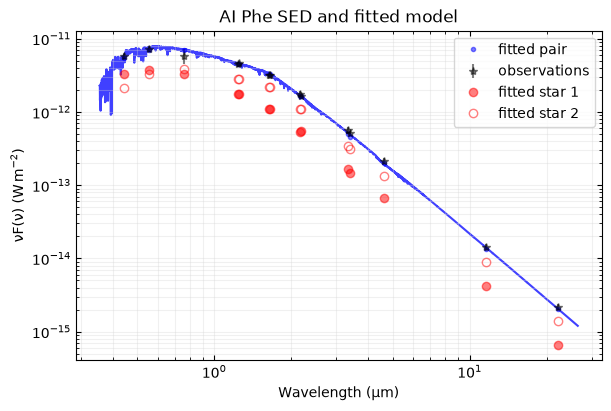

In [15]:
print(f"Fitted params from {sum(retain_mask)} retained fluxes.",
      "\nThose marked * were fitted. The values in brackets are from the input config.")
for (param, unit), val, fitted in zip(theta_labels, theta_min, fit_mask):
    known = target_config.get(param, np.NaN) if param in target_config else None
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:.3f} {unit:unicode}",
            f"\t ({known:.3f} {unit:unicode})" if known is not None else "")

fig = plot_fitted_model(sed[retain_mask], theta_min, model_grid, sed_flux_colname="sed_fit_flux",
                        show_combined_spectrum=True, show_component_spectra=False, show_grid=True,
                        title=f"{target_data['label']} SED and fitted model")
plt.show(fig)
plt.close(fig)

### Perform MCMC sampling for parameters with uncertainties

In [16]:
thin_by = 10 # sample every nth step from the chain
theta_mcmc, sampler = mcmc_fit(x[retain_mask],
                               y[retain_mask],
                               y_err[retain_mask],
                               theta0=theta0,
                               fit_mask=fit_mask,
                               ln_prior_func=ln_prior_func,
                               stellar_grid=model_grid,
                               nwalkers=100, nsteps=100000, thin_by=thin_by, processes=8, progress=True,
                               early_stopping=True, early_stopping_from=10000, verbose=True)

mcmc_fit(theta0=[6.700e+03*, 6.700e+03*, 4.000e+00, 4.000e+00, 1.000e+00*, 1.000e+00*, 1.693e+02*, 2.308e-01*])
Running MCMC fit on 8 process(es) with 100 walkers for 100000 steps, sampling every 10 steps.
Early stopping is considered after 10000 steps.


 10%|█         | 10000/100000 [15:04<2:15:43, 11.05it/s]


Halting MCMC after 10000 steps as the walkers are past 100 times the autocorrelation time & the fit has converged.
Mean Acceptance fraction:    0.509
Autocorrelation steps (tau): 72.476, 81.650, 73.592, 81.084, 65.269, 67.472
Estimated burn-in steps:     170
Leaving samples of shape:    (98300, 6) *flattened
The MCMC fit yielded theta:  [(6.485+/-0.326)e+03*, (5.192+/-0.258)e+03*, (4.000+/-0)e+00, (4.000+/-0)e+00, (1.804+/-0.098)e+00*, (2.919+/-0.123)e+00*, (1.693+/-0.005)e+02*, (2.452+/-1.175)e-01*]


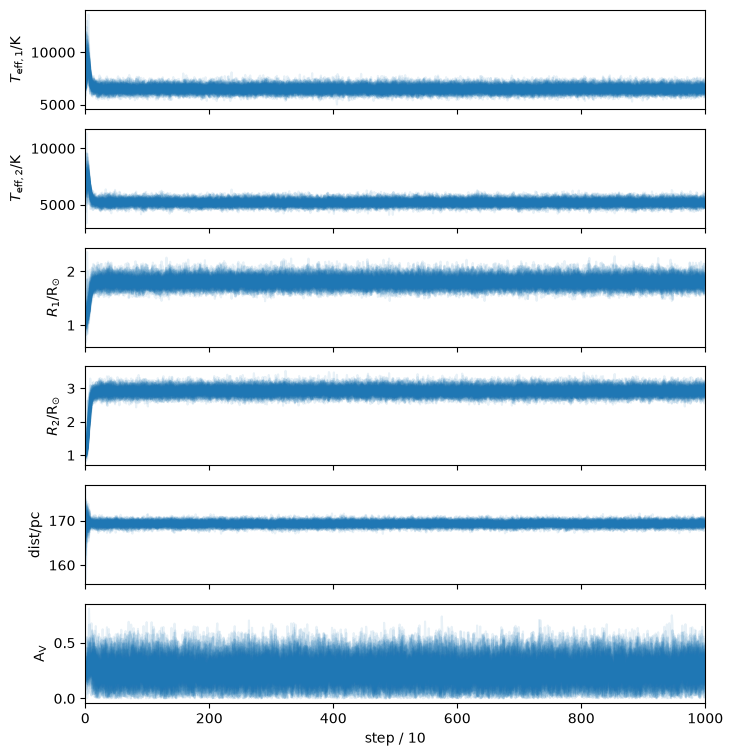

In [17]:
all_samples = sampler.get_chain()
fig, axes = plt.subplots(nrows=sum(fit_mask), figsize=(8, 1.5*sum(fit_mask)), sharex=True)
for ix, ax in enumerate(axes.flat):
    ax.plot(all_samples[:, :, ix], "tab:blue", alpha=0.1)
    ax.set(xlim=(0, len(all_samples)), ylabel=theta_plot_labels[fit_mask][ix])
axes[-1].set(xlabel=f"step / {thin_by}")
plt.show(fig)
plt.close()

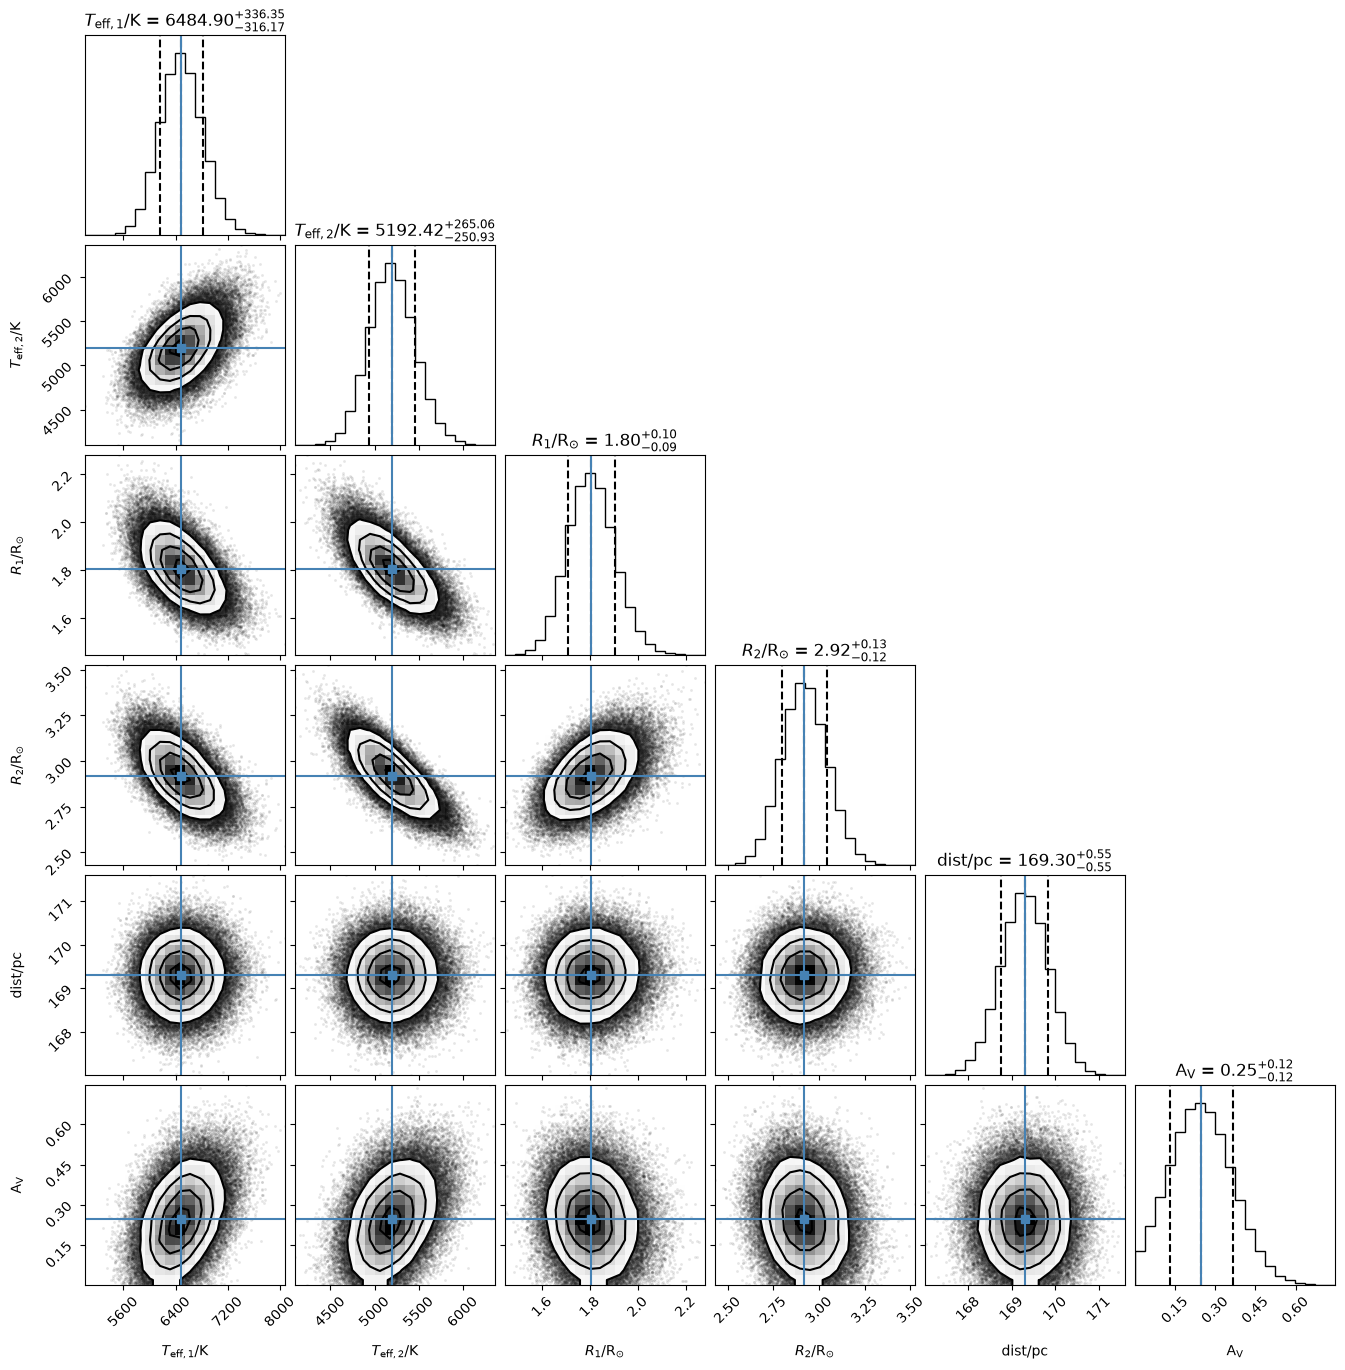

In [18]:
samples = samples_from_sampler(sampler, thin_by=thin_by, flat=True)
plt.show(corner.corner(samples, show_titles=True, plot_datapoints=True, quantiles=[0.16, 0.5, 0.84],
                       labels=theta_plot_labels[fit_mask], truths=nominal_values(theta_mcmc[fit_mask])))
plt.close()

Parameters for AI Phe with nominals & 1-sigma error bars from MCMC. 
Those marked * were fitted. The values in brackets are from the input config.
       Teff1* = 6484.902+/-326.258 K 	 (6257.000+/-0 K)
       Teff2* = 5192.424+/-257.997 K 	 (5100.000+/-0 K)
       logg1  = 4.000+/-0 dex 	 (4.002+/-0 dex)
       logg2  = 4.000+/-0 dex 	 (3.598+/-0 dex)
          R1* = 1.804+/-0.098 R☉ 	 (1.805+/-0.002 R☉)
          R2* = 2.919+/-0.123 R☉ 	 (2.933+/-0.002 R☉)
        dist* = 169.297+/-0.548 pc 
          av* = 0.245+/-0.117  


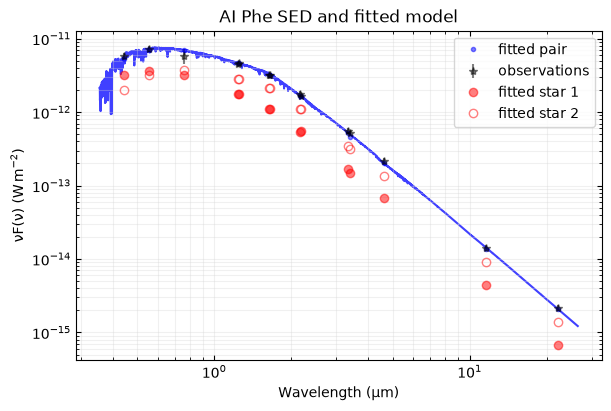

In [19]:
print(f"Parameters for {target} with nominals & 1-sigma error bars from MCMC.",
      "\nThose marked * were fitted. The values in brackets are from the input config.")
for (param, unit), val, fitted in zip(theta_labels, theta_mcmc, fit_mask):
    known = None
    if param in target_config:
        known = ufloat(target_config.get(param, np.NaN), target_config.get(param+"_err", None) or 0)
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:.3f} {unit:unicode}",
            f"\t ({known:.3f} {unit:unicode})" if known is not None else "")

fig = plot_fitted_model(sed[retain_mask], theta_mcmc, model_grid, sed_flux_colname="sed_fit_flux",
                        show_combined_spectrum=True, show_component_spectra=False, show_grid=True,
                        title=f"{target_data['label']} SED and fitted model")
plt.show(fig)
plt.close(fig)